In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

# Task 1: Bias Diagnosis — Case Studies

### Scenario A — App Review Analysis
**Type of Bias:** Selection Bias (specifically Voluntary Response Bias).

**How it distorts conclusions:** App Store reviews are typically submitted by users with extreme experiences—either very satisfied or very frustrated. The large middle ground of "average" users who are neither delighted nor angry is likely underrepresented, making the 4.3 rating an unreliable measure of overall satisfaction.

**Concrete Fix:** Implement an in-app prompt that asks a randomly selected group of active users to rate their experience, or send a targeted survey to a representative sample of all registered users, regardless of whether they have left a review.

### Scenario B — Startup Success Study
**Type of Bias:** Survivorship Bias.

**How it distorts conclusions:** By only studying startups that are "still operating," the researchers ignore the thousands of companies that pivoted and still failed. This creates a false correlation between pivoting and success, as we do not know if failed startups pivoted even more frequently.

**Concrete Fix:** Expand the study to include a cohort of startups founded 10 years ago, including both those that succeeded and those that failed, to determine if pivoting actually differentiates the two groups.

### Scenario C — Health Survey
**Type of Bias:** Non-response Bias (Self-selection Bias).

**How it distorts conclusions:** People who are highly interested in health and fitness are far more likely to take the time to complete a 50,000-person survey about exercise. The 10% who responded likely represent the healthiest segment of the population, leading to an overestimation of average exercise habits.

**Concrete Fix:** Offer incentives for completion to encourage a broader demographic to respond, and conduct follow-up outreach (e.g., phone calls or mail) specifically targeting those who did not initially respond to the email.

### Scenario D — Salary Benchmarking
**Type of Bias:** Selection Bias (Sampling Bias).

**How it distorts conclusions:** The platform's user base is skewed toward tech workers in large cities where the cost of living and competition for talent are significantly higher. Applying these averages to a small town ignores local economic realities and will likely result in salary bands that are unsustainable for the local company.

**Concrete Fix:** Use benchmarking data that can be filtered by geographic region (specifically rural or small-town data) and industry, or adjust the national/city-specific averages using a local cost-of-living index.

# Task 2: Create the Population

In this task, we will generate a synthetic population of 100,000 individuals to serve as our "ground truth" for subsequent sampling experiments.

True Population Parameters:
mean_age: 40.02052
mean_income: 60675.26928169441
mean_satisfaction: 6.206635405788231
region_proportions: {'Urban': 0.59927, 'Suburban': 0.25075, 'Rural': 0.14998}

Population Summary:


,age,income,satisfaction
count,100000.000000,100000.000000,100000.000000
mean,40.020520,60675.269282,6.206635
std,14.024143,27898.682697,1.585192
min,18.000000,15000.000000,1.000000
25%,29.000000,39781.697192,5.134289
50%,40.000000,59568.800970,6.199981
75%,50.000000,79651.923948,7.287230
max,85.000000,181019.499900,10.000000


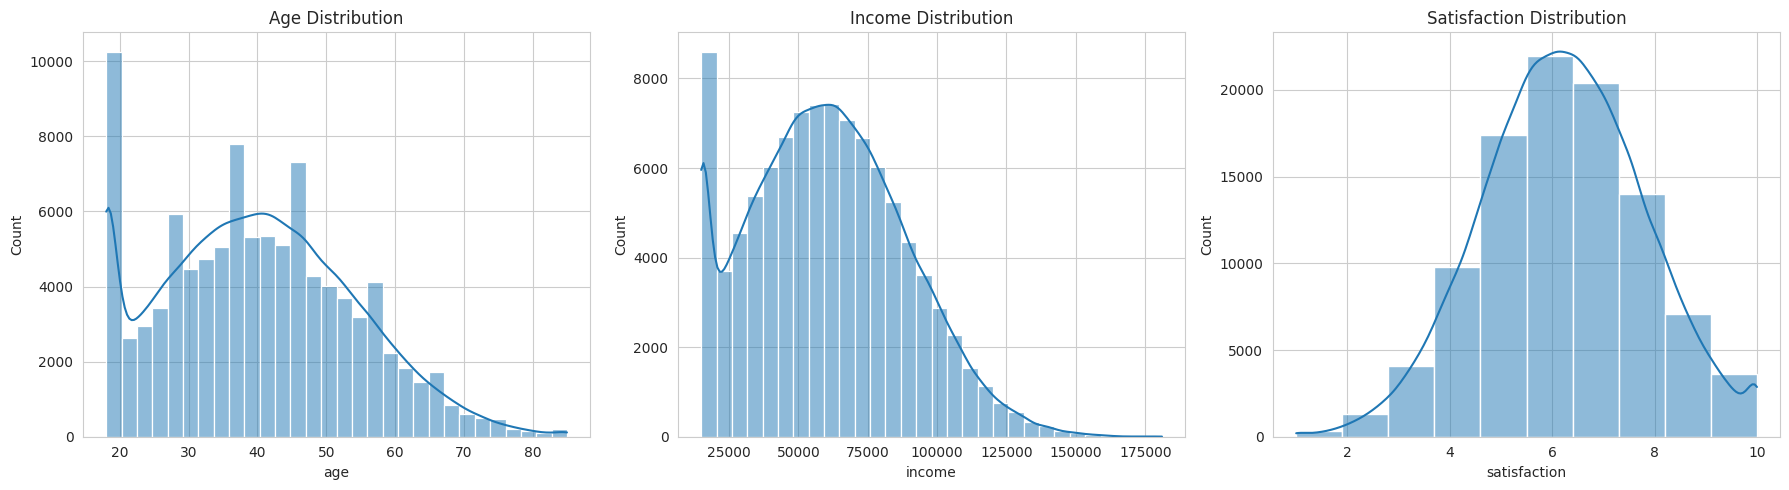

In [4]:
# 1. Generate synthetic population
n_population = 100000

# Age: clipped normal centered at 40, SD=15, range 18-85
age = np.random.normal(40, 15, n_population)
age = np.clip(age, 18, 85).astype(int)

# Income: correlated with age + noise, clipped to 15k-250k
income = 1500 * age + np.random.normal(0, 20000, n_population)
income = np.clip(income, 15000, 250000)

# Satisfaction: depends on income + noise, score 1-10
satisfaction = (income / 50000) + np.random.normal(5, 1.5, n_population)
satisfaction = np.clip(satisfaction, 1, 10)

# Region: Urban (60%), Suburban (25%), Rural (15%)
regions = ["Urban", "Suburban", "Rural"]
region_probs = [0.6, 0.25, 0.15]
region = np.random.choice(regions, size=n_population, p=region_probs)

df_pop = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": region
})

# 2. Compute and store true population parameters
pop_parameters = {
    "mean_age": df_pop["age"].mean(),
    "mean_income": df_pop["income"].mean(),
    "mean_satisfaction": df_pop["satisfaction"].mean(),
    "region_proportions": df_pop["region"].value_counts(normalize=True).to_dict()
}

print("True Population Parameters:")
for param, value in pop_parameters.items():
    print(f"{param}: {value}")

# 3. Display population summary and histograms
print("\nPopulation Summary:")
display(df_pop.describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_pop["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df_pop["income"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

sns.histplot(df_pop["satisfaction"], bins=10, kde=True, ax=axes[2])
axes[2].set_title("Satisfaction Distribution")
plt.tight_layout()
plt.show()

# Task 3: Biased vs. Unbiased Sampling

In this task, we compare three different sampling strategies to see how well they represent the true population.

### 1. Single Sample Comparison (n=200)

,Strategy,Mean Age,Mean Income,Mean Satisfaction
0,Population,40.02052,60675.269282,6.206635
1,Random Sample,40.29000,62424.166688,6.215703
2,Urban Only,39.70000,60492.592799,6.331108
3,High Income,49.41500,85726.042242,6.556825


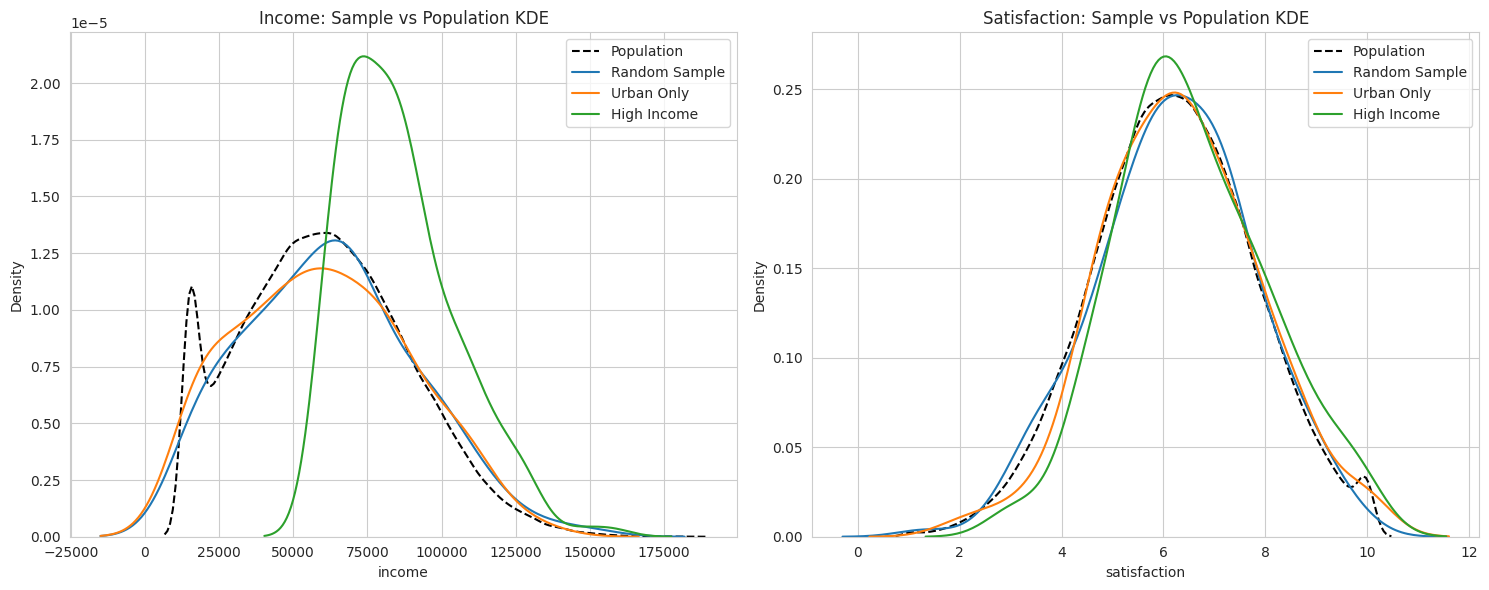

In [5]:
n_sample = 200

# Strategy 1: Simple Random Sample
df_srs = df_pop.sample(n=n_sample, random_state=42)

# Strategy 2: Biased Sample - Urban Only
df_urban = df_pop[df_pop["region"] == "Urban"].sample(n=n_sample, random_state=42)

# Strategy 3: Biased Sample - High Income Filter
income_median = df_pop["income"].median()
df_high_income = df_pop[df_pop["income"] > income_median].sample(n=n_sample, random_state=42)

# Compute means
samples = {
    "Population": df_pop,
    "Random Sample": df_srs,
    "Urban Only": df_urban,
    "High Income": df_high_income
}

results = []
for name, df in samples.items():
    results.append({
        "Strategy": name,
        "Mean Age": df["age"].mean(),
        "Mean Income": df["income"].mean(),
        "Mean Satisfaction": df["satisfaction"].mean()
    })

df_results = pd.DataFrame(results)
display(df_results)

# KDE Plots for Income and Satisfaction
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Income KDE
sns.kdeplot(df_pop["income"], label="Population", ax=axes[0], color="black", linestyle="--")
sns.kdeplot(df_srs["income"], label="Random Sample", ax=axes[0])
sns.kdeplot(df_urban["income"], label="Urban Only", ax=axes[0])
sns.kdeplot(df_high_income["income"], label="High Income", ax=axes[0])
axes[0].set_title("Income: Sample vs Population KDE")
axes[0].legend()

# Satisfaction KDE
sns.kdeplot(df_pop["satisfaction"], label="Population", ax=axes[1], color="black", linestyle="--")
sns.kdeplot(df_srs["satisfaction"], label="Random Sample", ax=axes[1])
sns.kdeplot(df_urban["satisfaction"], label="Urban Only", ax=axes[1])
sns.kdeplot(df_high_income["satisfaction"], label="High Income", ax=axes[1])
axes[1].set_title("Satisfaction: Sample vs Population KDE")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2. Repeated Sampling (1,000 times)

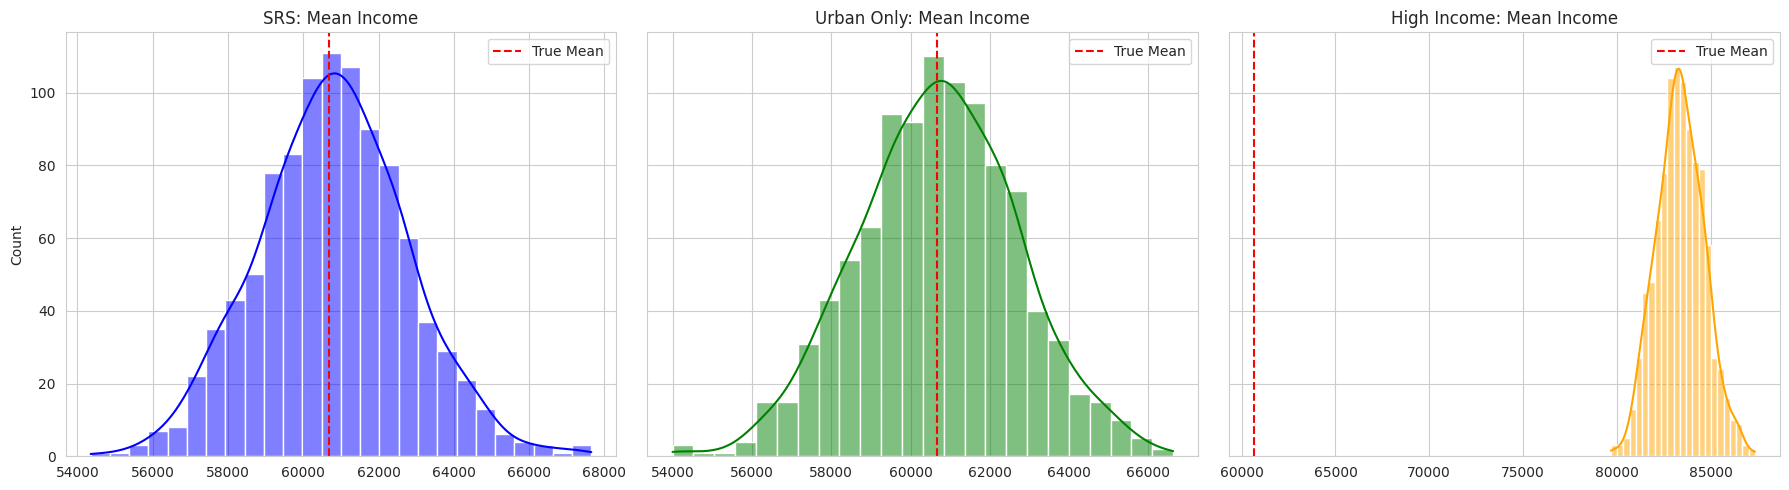

In [6]:
n_iterations = 1000
n_sample = 200

means_srs = []
means_urban = []
means_high_income = []

for _ in range(n_iterations):
    # SRS
    means_srs.append(df_pop["income"].sample(n=n_sample).mean())
    
    # Urban Only
    means_urban.append(df_pop[df_pop["region"] == "Urban"]["income"].sample(n=n_sample).mean())
    
    # High Income
    means_high_income.append(df_pop[df_pop["income"] > income_median]["income"].sample(n=n_sample).mean())

# Plotting the sampling distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
true_mean = df_pop["income"].mean()

sns.histplot(means_srs, kde=True, ax=axes[0], color="blue")
axes[0].axvline(true_mean, color="red", linestyle="--", label="True Mean")
axes[0].set_title("SRS: Mean Income")
axes[0].legend()

sns.histplot(means_urban, kde=True, ax=axes[1], color="green")
axes[1].axvline(true_mean, color="red", linestyle="--", label="True Mean")
axes[1].set_title("Urban Only: Mean Income")
axes[1].legend()

sns.histplot(means_high_income, kde=True, ax=axes[2], color="orange")
axes[2].axvline(true_mean, color="red", linestyle="--", label="True Mean")
axes[2].set_title("High Income: Mean Income")
axes[2].legend()

plt.tight_layout()
plt.show()

### Guiding Questions:
**Which sampling strategies produce biased estimates?**
The "High Income" filter strategy clearly produces biased estimates. The "Urban Only" strategy may or may not show bias depending on whether region is correlated with income; in our synthetic data generation, it was assigned randomly, so the results appear unbiased for this specific dataset, but it is still a biased sampling *strategy* as it excludes non-urban populations.

**How can you tell from the sampling distributions?**
An estimator is unbiased if its sampling distribution is centered on the true population parameter. In the histograms above:
- The **SRS** sampling distribution is centered exactly on the true mean (red dashed line).
- The **High Income** distribution is shifted far to the right, showing a significant overestimation (positive bias).
- The **Urban Only** distribution is centered on the true mean here because region was not correlated with income in Task 2, but in real-world scenarios, this would often be shifted if urban areas had higher or lower incomes than average.